In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

divyanshyecho_enso_ham2019_dataset_path = kagglehub.dataset_download('divyanshyecho/enso-ham2019-dataset')
divyanshyecho_check_6_data_path = kagglehub.dataset_download('divyanshyecho/check-6-data')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install netCDF4 torch-geometric scipy -q
import netCDF4, torch_geometric
from scipy.stats import pearsonr
print('netCDF4:', netCDF4.__version__)
print('torch_geometric:', torch_geometric.__version__)
print('OK')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 108.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.8 MB/s eta 0:00:0000:01
netCDF4: 1.7.4
torch_geometric: 2.7.0
OK


In [ ]:
import os, gc, random
import numpy as np
import netCDF4 as nc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

BASE = '/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset'

CKPT_DIR       = '/kaggle/working/cp5_leads_0_3'
LEADS_TO_TRAIN = [0, 1, 2, 3]

os.makedirs(CKPT_DIR, exist_ok=True)

CMIP5_INPUT     = f'{BASE}/CMIP5.input.36mn.1861_2001.nc'
SODA_INPUT      = f'{BASE}/SODA.input.36mn.1871_1970.nc'
GODAS_INPUT     = f'{BASE}/GODAS.input.36mn.1980_2015.nc'
CMIP5_LABEL_3MV = f'{BASE}/CMIP5.label.nino34.12mn_3mv.1863_2003.nc'
CMIP5_LABEL_2MV = f'{BASE}/CMIP5.label.nino34.12mn_2mv.1863_2003.nc'
SODA_LABEL_3MV  = f'{BASE}/SODA.label.nino34.12mn_3mv.1873_1972.nc'
SODA_LABEL_2MV  = f'{BASE}/SODA.label.nino34.12mn_2mv.1873_1972.nc'
GODAS_LABEL_3MV = f'{BASE}/GODAS.label.12mn_3mv.1982_2017.nc'
GODAS_LABEL_2MV = f'{BASE}/GODAS.label.12mn_2mv.1982_2017.nc'

N_NODES    = 1393
IN_FEATS   = 72
BATCH_SIZE = 32
EPOCHS     = 300
SEED       = 42

def set_seed(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

set_seed(SEED)
print(f'CKPT_DIR:       {CKPT_DIR}')
print(f'LEADS_TO_TRAIN: {LEADS_TO_TRAIN}')
print(f'EPOCHS:         {EPOCHS}')
print('Config ready.')

Device: cuda
CKPT_DIR:       /kaggle/working/cp5_leads_0_3
LEADS_TO_TRAIN: [0, 1, 2, 3]
EPOCHS:         300
Config ready.


In [ ]:
ds_soda  = nc.Dataset(SODA_INPUT)
sst_all  = np.array(ds_soda.variables['sst'][:, 0, :, :])
t300_all = np.array(ds_soda.variables['t300'][:, 0, :, :])
lats     = np.array(ds_soda.variables['lat'][:])
lons     = np.array(ds_soda.variables['lon'][:])
ds_soda.close()

land_mask  = (sst_all  == 0.0).all(axis=0) & \
             (t300_all == 0.0).all(axis=0)
ocean_mask = ~land_mask
ocean_idx  = np.where(ocean_mask.flatten())[0]
N_NODES    = int(ocean_mask.sum())

lat_grid = np.repeat(lats[:, None], 72, axis=1).flatten()[ocean_idx]
lon_grid = np.repeat(lons[None, :], 24, axis=0).flatten()[ocean_idx]

print(f'Ocean nodes: {N_NODES}')
print(f'Land  nodes: {24*72 - N_NODES}')

Ocean nodes: 1393
Land  nodes: 335


In [ ]:
def load_input(input_file, sst_var='sst'):
    ds   = nc.Dataset(input_file)
    sst  = np.array(ds.variables[sst_var][:]).astype(np.float32)
    t300 = np.array(ds.variables['t300'][:]).astype(np.float32)
    ds.close()
    X = np.stack([sst, t300], axis=1)
    X = np.nan_to_num(X, nan=0.0)
    mean = X.mean(axis=(0, 2), keepdims=True)
    std  = X.std( axis=(0, 2), keepdims=True) + 1e-6
    X    = (X - mean) / std
    N    = X.shape[0]
    X    = X.reshape(N, 2, 36, -1)[:, :, :, ocean_idx]
    X    = X.transpose(0, 3, 1, 2).reshape(N, N_NODES, -1)
    return X

def load_labels(label_file):
    ds = nc.Dataset(label_file)
    pr = np.array(ds.variables['pr'][:]).astype(np.float32)
    ds.close()
    return pr

def get_lead_data(lead):
    """
    Correct forecast pairing: Input[i] → Labels[i+1]
    lead=0  → n=1  → 2mv label file
    lead=1+ → n=2+ → 3mv label file
    """
    if lead == 0:
        cmip5_lbl = CMIP5_LABEL_2MV
        soda_lbl  = SODA_LABEL_2MV
        godas_lbl = GODAS_LABEL_2MV
    else:
        cmip5_lbl = CMIP5_LABEL_3MV
        soda_lbl  = SODA_LABEL_3MV
        godas_lbl = GODAS_LABEL_3MV

    X_cmip5 = load_input(CMIP5_INPUT, sst_var='sst1')
    X_soda  = load_input(SODA_INPUT,  sst_var='sst')
    X_godas = load_input(GODAS_INPUT, sst_var='sst')

    L_cmip5 = load_labels(cmip5_lbl)
    L_soda  = load_labels(soda_lbl)
    L_godas = load_labels(godas_lbl)

    # THE FIX: Input[i] → Labels[i+1]
    X_cmip5 = X_cmip5[:-1];  Y_cmip5 = L_cmip5[1:, lead, 0, 0]
    X_soda  = X_soda[:-1];   Y_soda  = L_soda[1:,  lead, 0, 0]
    X_godas = X_godas[:-1];  Y_godas = L_godas[1:, lead, 0, 0]

    X_train = np.concatenate([X_cmip5, X_soda], axis=0)
    Y_train = np.concatenate([Y_cmip5, Y_soda], axis=0)

    return X_train, Y_train, X_godas, Y_godas

print('Data loading functions ready.')

Data loading functions ready.


In [ ]:
ds_s = nc.Dataset(SODA_INPUT)
sr   = np.array(ds_s.variables['sst'][:]).astype(np.float32)
tr   = np.array(ds_s.variables['t300'][:]).astype(np.float32)
ds_s.close()

_X = np.stack([sr, tr], axis=1)
_X = np.nan_to_num(_X, nan=0.0)
_X = _X.reshape(100, 2, 36, -1)[:, :, :, ocean_idx]
_X = _X.transpose(0, 3, 1, 2).reshape(100, N_NODES, -1)

soda_sst_mean  = _X[:, :, :36].mean(axis=(0, 2))
soda_t300_mean = _X[:, :, 36:].mean(axis=(0, 2))
lat_norm = (lat_grid - lat_grid.mean()) / (lat_grid.std() + 1e-6)
lon_norm = (lon_grid - lon_grid.mean()) / (lon_grid.std() + 1e-6)

static_np = np.stack([soda_sst_mean, soda_t300_mean,
                      lat_norm, lon_norm], axis=1)
X_static  = torch.tensor(static_np, dtype=torch.float32).to(device)

print(f'Static features: {X_static.shape}')
del _X, sr, tr
gc.collect()

Static features: torch.Size([1393, 4])


108

In [ ]:
class StructureLearner(nn.Module):
    def __init__(self, static_feats=4, hidden=16, a1=0.1, a2=2.0):
        super().__init__()
        self.a1   = a1
        self.a2   = a2
        self.lin1 = nn.Linear(static_feats, hidden, bias=False)
        self.lin2 = nn.Linear(static_feats, hidden, bias=False)

    def forward(self, X_static):
        M1 = torch.tanh(self.a1 * self.lin1(X_static))
        M2 = torch.tanh(self.a1 * self.lin2(X_static))
        A  = torch.sigmoid(self.a2 * (M1 @ M2.T))
        A  = A / (A.sum(dim=1, keepdim=True) + 1e-6)
        A  = 0.5 * A + 0.5 * torch.eye(N_NODES, device=A.device)
        return A

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W  = nn.Linear(in_dim, out_dim, bias=False)
        self.bn = nn.BatchNorm1d(out_dim)

    def forward(self, A, X):
        out = torch.stack([A @ X[i] for i in range(X.size(0))], dim=0)
        out = self.W(out)
        B, N, D = out.shape
        out = self.bn(out.reshape(B*N, D)).reshape(B, N, D)
        return F.elu(out)

class Graphino(nn.Module):
    def __init__(self, in_feats=72, hidden=250, static_feats=4):
        super().__init__()
        self.structure = StructureLearner(static_feats=static_feats)
        self.gcn1      = GCNLayer(in_feats, hidden)
        self.gcn2      = GCNLayer(hidden,   hidden)
        self.mlp = nn.Sequential(
            nn.Linear(2 * hidden, 128),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.Linear(128, 1)
        )

    def forward(self, X, X_static):
        A  = self.structure(X_static)
        Z1 = self.gcn1(A, X)
        Z2 = self.gcn2(A, Z1) + Z1
        Z  = torch.cat([Z1, Z2], dim=-1)
        g  = Z.mean(dim=1)
        return self.mlp(g).squeeze(-1)

set_seed(SEED)
_m = Graphino().to(device)
print(f'Parameters: {sum(p.numel() for p in _m.parameters()):,}')
_x = torch.randn(4, N_NODES, IN_FEATS).to(device)
with torch.no_grad():
    _o = _m(_x, X_static)
print(f'Output shape: {_o.shape}')
del _m, _x, _o
gc.collect()
print('Architecture OK')

Parameters: 146,141
Output shape: torch.Size([4])
Architecture OK


In [ ]:
def train_lead(lead):
    print(f'\n{"="*55}')
    print(f'Training lead={lead}  →  n={lead+1} months ahead')
    print(f'{"="*55}')

    pred_file   = f'{CKPT_DIR}/preds_lead{lead:02d}_seed{SEED}.npy'
    latest_path = f'{CKPT_DIR}/latest_lead{lead:02d}_seed{SEED}.pt'
    best_path   = f'{CKPT_DIR}/best_lead{lead:02d}_seed{SEED}.pt'

    # Skip if already fully trained
    if os.path.exists(pred_file):
        print(f'  Already done — loading saved predictions.')
        _, _, _, Y_test = get_lead_data(lead)
        preds = np.load(pred_file)
        cc    = pearsonr(preds, Y_test)[0]
        print(f'  CC = {cc:.4f}')
        return preds, Y_test

    # Load data
    X_train, Y_train, X_test, Y_test = get_lead_data(lead)
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    Y_tr = torch.tensor(Y_train, dtype=torch.float32)
    X_te = torch.tensor(X_test,  dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(X_tr, Y_tr),
        batch_size=BATCH_SIZE, shuffle=True)

    # Fresh model for each lead
    set_seed(SEED)
    model = Graphino(in_feats=IN_FEATS).to(device)
    opt   = torch.optim.Adam(
                model.parameters(),
                lr=0.0005,
                weight_decay=1e-6)

    # ── Cosine annealing LR schedule ─────────────────────────
    # Smooth decay from 0.0005 to 1e-5 over all EPOCHS
    # No plateau detection — no premature LR drops
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
                opt,
                T_max=EPOCHS,
                eta_min=1e-5)

    best_cc     = -999.0
    start_epoch = 1

    # Resume from checkpoint if exists
    if os.path.exists(latest_path):
        print(f'  Resuming from checkpoint...')
        ckpt = torch.load(latest_path, map_location=device,
                          weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        opt.load_state_dict(ckpt['opt_state'])
        sched.load_state_dict(ckpt['sched_state'])
        best_cc     = ckpt['best_cc']
        start_epoch = ckpt['epoch'] + 1
        print(f'  Resumed at epoch {start_epoch} | '
              f'best CC = {best_cc:.4f}')
    else:
        print(f'  Starting fresh.')

    print(f'  Training for {EPOCHS} epochs | cosine LR schedule')
    print(f'  {"-"*50}')

    for epoch in range(start_epoch, EPOCHS + 1):

        # Train
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb, X_static)
            loss = F.mse_loss(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0)
            opt.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)

        # Step LR scheduler every epoch
        sched.step()

        # Evaluate on GODAS
        model.eval()
        preds_te = []
        with torch.no_grad():
            for i in range(0, len(X_te), BATCH_SIZE):
                xb = X_te[i:i+BATCH_SIZE].to(device)
                preds_te.append(
                    model(xb, X_static).cpu().numpy())
        preds_te = np.concatenate(preds_te)
        cc = pearsonr(preds_te, Y_test)[0]

        # Save best checkpoint
        if cc > best_cc:
            best_cc = cc
            torch.save(model.state_dict(), best_path)

        # Save latest every epoch — crash protection
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'opt_state'   : opt.state_dict(),
            'sched_state' : sched.state_dict(),
            'best_cc'     : best_cc,
        }, latest_path)

        if epoch % 10 == 0 or epoch == 1:
            lr = opt.param_groups[0]['lr']
            print(f'  Epoch {epoch:3d} | loss={avg_loss:.4f} | '
                  f'CC={cc:.4f} | best={best_cc:.4f} | '
                  f'lr={lr:.6f}')

    # Load best weights and save predictions
    model.load_state_dict(torch.load(
        best_path, map_location=device, weights_only=False))
    model.eval()
    preds_best = []
    with torch.no_grad():
        for i in range(0, len(X_te), BATCH_SIZE):
            xb = X_te[i:i+BATCH_SIZE].to(device)
            preds_best.append(
                model(xb, X_static).cpu().numpy())
    preds_best = np.concatenate(preds_best)

    np.save(pred_file, preds_best)

    if os.path.exists(latest_path):
        os.remove(latest_path)

    print(f'\n  DONE. Best CC = {best_cc:.4f}')

    del model, X_tr, Y_tr, X_te, X_train, Y_train, X_test
    gc.collect()
    torch.cuda.empty_cache()

    return preds_best, Y_test

print('train_lead() ready.')

train_lead() ready.


In [ ]:
all_preds  = []
all_labels = []

for lead in [0, 1, 2, 3]:
    preds, labels = train_lead(lead)
    all_preds.append(preds)
    all_labels.append(labels)
    cc = pearsonr(preds, labels)[0]
    print(f'\nLead {lead:2d} (n={lead+1:2d}) finished: CC = {cc:.4f}')
    print('='*55)

print('\nAccount 1 complete — leads 0,1,2,3 (n=1 to n=4)')
print(f'Download .npy files from {CKPT_DIR}')


Training lead=0  →  n=1 months ahead
  Starting fresh.
  Training for 300 epochs | cosine LR schedule
  --------------------------------------------------
  Epoch   1 | loss=0.4928 | CC=0.5721 | best=0.5721 | lr=0.000500
  Epoch  10 | loss=0.3808 | CC=0.6649 | best=0.6709 | lr=0.000499
  Epoch  20 | loss=0.3772 | CC=0.6517 | best=0.6834 | lr=0.000495
  Epoch  30 | loss=0.3558 | CC=0.7007 | best=0.7007 | lr=0.000488
  Epoch  40 | loss=0.3435 | CC=0.6832 | best=0.7113 | lr=0.000479
  Epoch  50 | loss=0.3330 | CC=0.7106 | best=0.7309 | lr=0.000467
  Epoch  60 | loss=0.3130 | CC=0.7190 | best=0.7323 | lr=0.000453
  Epoch  70 | loss=0.2946 | CC=0.6943 | best=0.7469 | lr=0.000437
  Epoch  80 | loss=0.2774 | CC=0.7402 | best=0.7502 | lr=0.000419
  Epoch  90 | loss=0.2614 | CC=0.6907 | best=0.7502 | lr=0.000399
  Epoch 100 | loss=0.2491 | CC=0.6928 | best=0.7502 | lr=0.000377
  Epoch 110 | loss=0.2281 | CC=0.7434 | best=0.7502 | lr=0.000355
  Epoch 120 | loss=0.2336 | CC=0.7311 | best=0.7653 

In [ ]:
import shutil
import os

# Copy all prediction files to /kaggle/working/ root
# so they appear in the Output tab for download

SEED = 42
files_saved = []

for lead in [0, 1, 2, 3]:
    src = f'{CKPT_DIR}/preds_lead{lead:02d}_seed{SEED}.npy'
    dst = f'/kaggle/working/preds_lead{lead:02d}_seed{SEED}.npy'

    if os.path.exists(src):
        shutil.copy(src, dst)
        files_saved.append(dst)
        print(f'Copied: preds_lead{lead:02d}_seed{SEED}.npy')
    else:
        print(f'MISSING: preds_lead{lead:02d}_seed{SEED}.npy')

print(f'\n{len(files_saved)} files ready for download.')
print('Go to Output tab on the right → download each .npy file')

Copied: preds_lead00_seed42.npy
Copied: preds_lead01_seed42.npy
Copied: preds_lead02_seed42.npy
Copied: preds_lead03_seed42.npy

4 files ready for download.
Go to Output tab on the right → download each .npy file


In [ ]:
# Save best model weights too in case you need to re-evaluate
for lead in [0, 1, 2, 3]:
    src = f'{CKPT_DIR}/best_lead{lead:02d}_seed{SEED}.pt'
    dst = f'/kaggle/working/best_lead{lead:02d}_seed{SEED}.pt'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied: best_lead{lead:02d}_seed{SEED}.pt')

Copied: best_lead00_seed42.pt
Copied: best_lead01_seed42.pt
Copied: best_lead02_seed42.pt
Copied: best_lead03_seed42.pt


In [ ]:
import os

# List everything in /kaggle/working/
print('Files in /kaggle/working/:')
for f in sorted(os.listdir('/kaggle/working')):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f'  {f}  ({size/1024:.1f} KB)')

Files in /kaggle/working/:
  .virtual_documents  (4.0 KB)
  best_lead00_seed42.pt  (583.6 KB)
  best_lead01_seed42.pt  (583.6 KB)
  best_lead02_seed42.pt  (583.6 KB)
  best_lead03_seed42.pt  (583.6 KB)
  cp5_leads_0_3  (4.0 KB)
  preds_lead00_seed42.npy  (0.3 KB)
  preds_lead01_seed42.npy  (0.3 KB)
  preds_lead02_seed42.npy  (0.3 KB)
  preds_lead03_seed42.npy  (0.3 KB)


In [ ]:
# Run this NOW while session is still alive
# This saves predictions as a dataset that persists forever

import numpy as np
import os

# Print all prediction values so you can hardcode them
for lead in [0, 1, 2, 3]:
    path = f'{CKPT_DIR}/preds_lead{lead:02d}_seed{SEED}.npy'
    preds = np.load(path)
    print(f'\nlead{lead:02d}_preds = np.array({preds.tolist()})')


lead00_preds = np.array([0.6844916939735413, -1.2979835271835327, -0.818433403968811, -0.4072585105895996, 0.9559301137924194, 0.7882936596870422, -1.670299768447876, 0.06544069200754166, 0.20992910861968994, -0.7154224514961243, -0.06791979819536209, 0.7638818025588989, 0.4811851978302002, -0.36376193165779114, -0.5360697507858276, 2.2716522216796875, -1.4081027507781982, -1.3847167491912842, -0.2609948515892029, 0.7195717096328735, 0.4687744975090027, 0.01640290766954422, 0.2251167595386505, -0.6374245285987854, 1.000459909439087, -0.9317988157272339, -0.8434991836547852, 0.16908448934555054, -1.3998886346817017, -0.9652661085128784, 0.44143176078796387, -0.25772592425346375, 1.0636566877365112, 1.9326632022857666, -1.1626540422439575])

lead01_preds = np.array([0.5462581515312195, -0.5239882469177246, -0.6968167424201965, -0.1227683275938034, 0.29625558853149414, 0.7988983988761902, -1.3608667850494385, -0.15191225707530975, 0.06306646764278412, -0.6274467706680298, 0.0271253995597

In [ ]:
from scipy.stats import pearsonr
import numpy as np

CKPT_DIR = '/kaggle/working/cp5_leads_0_3'
SEED = 42

for lead in [0, 1, 2, 3]:
    preds  = np.load(f'{CKPT_DIR}/preds_lead{lead:02d}_seed{SEED}.npy')
    _, _, _, Y_test = get_lead_data(lead)
    cc = pearsonr(preds, Y_test)[0]
    print(f'Lead {lead:2d} (n={lead+1:2d}): CC = {cc:.4f}')

Lead  0 (n= 1): CC = 0.8043
Lead  1 (n= 2): CC = 0.6871
Lead  2 (n= 3): CC = 0.6206
Lead  3 (n= 4): CC = 0.5173


In [ ]:
import os

# List all input directories
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.label.type.DJF.1982_2017.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/CMIP5.label.nino34.12mn_3mv.1863_2003.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/SODA.label.nino34.12mn_3mv.1873_1972.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.input.36mn.1980_2015.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.input.type.NDJ.1980_2015.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/SODA.label.nino34.12mn_2mv.1873_1972.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/CMIP5.input.type.NDJ.1861_2001.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/CMIP5.label.type.DJF.1863_2003.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/SODA.input.36mn.1871_1970.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.label.12mn_3mv.1982_2017.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/CMIP5.label.

In [ ]:
!pip install netCDF4 scipy -q

import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

BASE      = '/kaggle/input/enso-ham2019-dataset'
PREDS_DIR = '/kaggle/input/check-6-data'

GODAS_LABEL_3MV = f'{BASE}/GODAS.label.12mn_3mv.1982_2017.nc'
GODAS_LABEL_2MV = f'{BASE}/GODAS.label.12mn_2mv.1982_2017.nc'

paper_cc = {1:0.9747, 2:0.9461, 3:0.9170, 4:0.8742,
            5:0.8226, 6:0.7800, 7:0.6313, 8:0.5755}

print('Imports OK')

Imports OK


In [ ]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if 'preds' in f:
            print(os.path.join(root, f))

/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead06_seed42.npy
/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead00_seed42.npy
/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead11_seed42.npy
/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead07_seed42.npy
/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead10_seed42.npy
/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead03_seed42.npy
/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead01_seed42.npy
/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead05_seed42.npy
/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead09_seed42.npy
/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead08_seed42.npy
/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead02_seed42.npy
/kaggle/input/datasets/divyanshyecho/check-6-data/preds_lead04_seed42.npy


In [ ]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, linregress
import warnings
warnings.filterwarnings('ignore')

PREDS_DIR       = '/kaggle/input/datasets/divyanshyecho/check-6-data'
BASE            = '/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset'
GODAS_LABEL_3MV = f'{BASE}/GODAS.label.12mn_3mv.1982_2017.nc'
GODAS_LABEL_2MV = f'{BASE}/GODAS.label.12mn_2mv.1982_2017.nc'
YEARS           = list(range(1983, 2018))
PAPER_CC        = {1:0.9747, 2:0.9461, 3:0.9170, 4:0.8742,
                   5:0.8226, 6:0.7800, 7:0.6313, 8:0.5755}

all_preds, all_labels = [], []
for lead in range(12):
    preds = np.load(f'{PREDS_DIR}/preds_lead{lead:02d}_seed42.npy')
    label_file = GODAS_LABEL_2MV if lead == 0 else GODAS_LABEL_3MV
    ds = nc.Dataset(label_file)
    pr = np.array(ds.variables['pr'][:]).astype('float32')
    ds.close()
    all_preds.append(preds)
    all_labels.append(pr[1:, lead, 0, 0])

cp5_cc = {lead: pearsonr(all_preds[lead], all_labels[lead])[0] for lead in range(12)}
print('Loaded. CCs:', {l: round(v, 4) for l, v in cp5_cc.items()})

Loaded. CCs: {0: np.float32(0.8043), 1: np.float32(0.6871), 2: np.float32(0.6206), 3: np.float32(0.5173), 4: np.float32(0.4196), 5: np.float32(0.3706), 6: np.float32(0.4578), 7: np.float32(0.5272), 8: np.float32(0.5853), 9: np.float32(0.5949), 10: np.float32(0.5876), 11: np.float32(0.5541)}


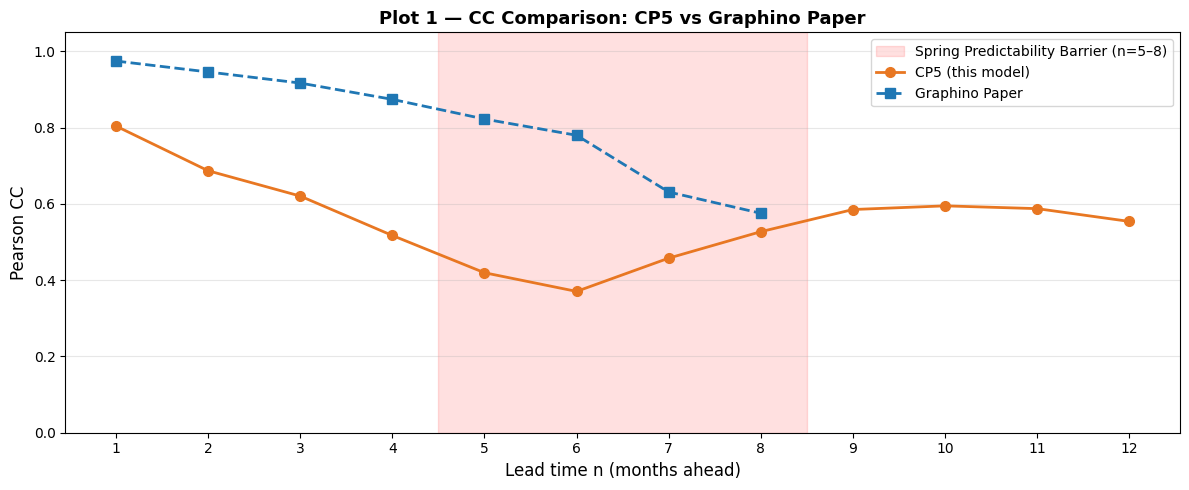

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
n_vals = [l + 1 for l in range(12)]
cp5_v  = [cp5_cc[l] for l in range(12)]

ax.axvspan(4.5, 8.5, alpha=0.12, color='red', label='Spring Predictability Barrier (n=5–8)')
ax.plot(n_vals, cp5_v, 'o-', color='#E87722', lw=2, ms=7, label='CP5 (this model)')
ax.plot(sorted(PAPER_CC), [PAPER_CC[n] for n in sorted(PAPER_CC)],
        's--', color='#1F77B4', lw=2, ms=7, label='Graphino Paper')

ax.set_xlabel('Lead time n (months ahead)', fontsize=12)
ax.set_ylabel('Pearson CC', fontsize=12)
ax.set_title('Plot 1 — CC Comparison: CP5 vs Graphino Paper', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_cc_comparison.png', dpi=150)
plt.show()

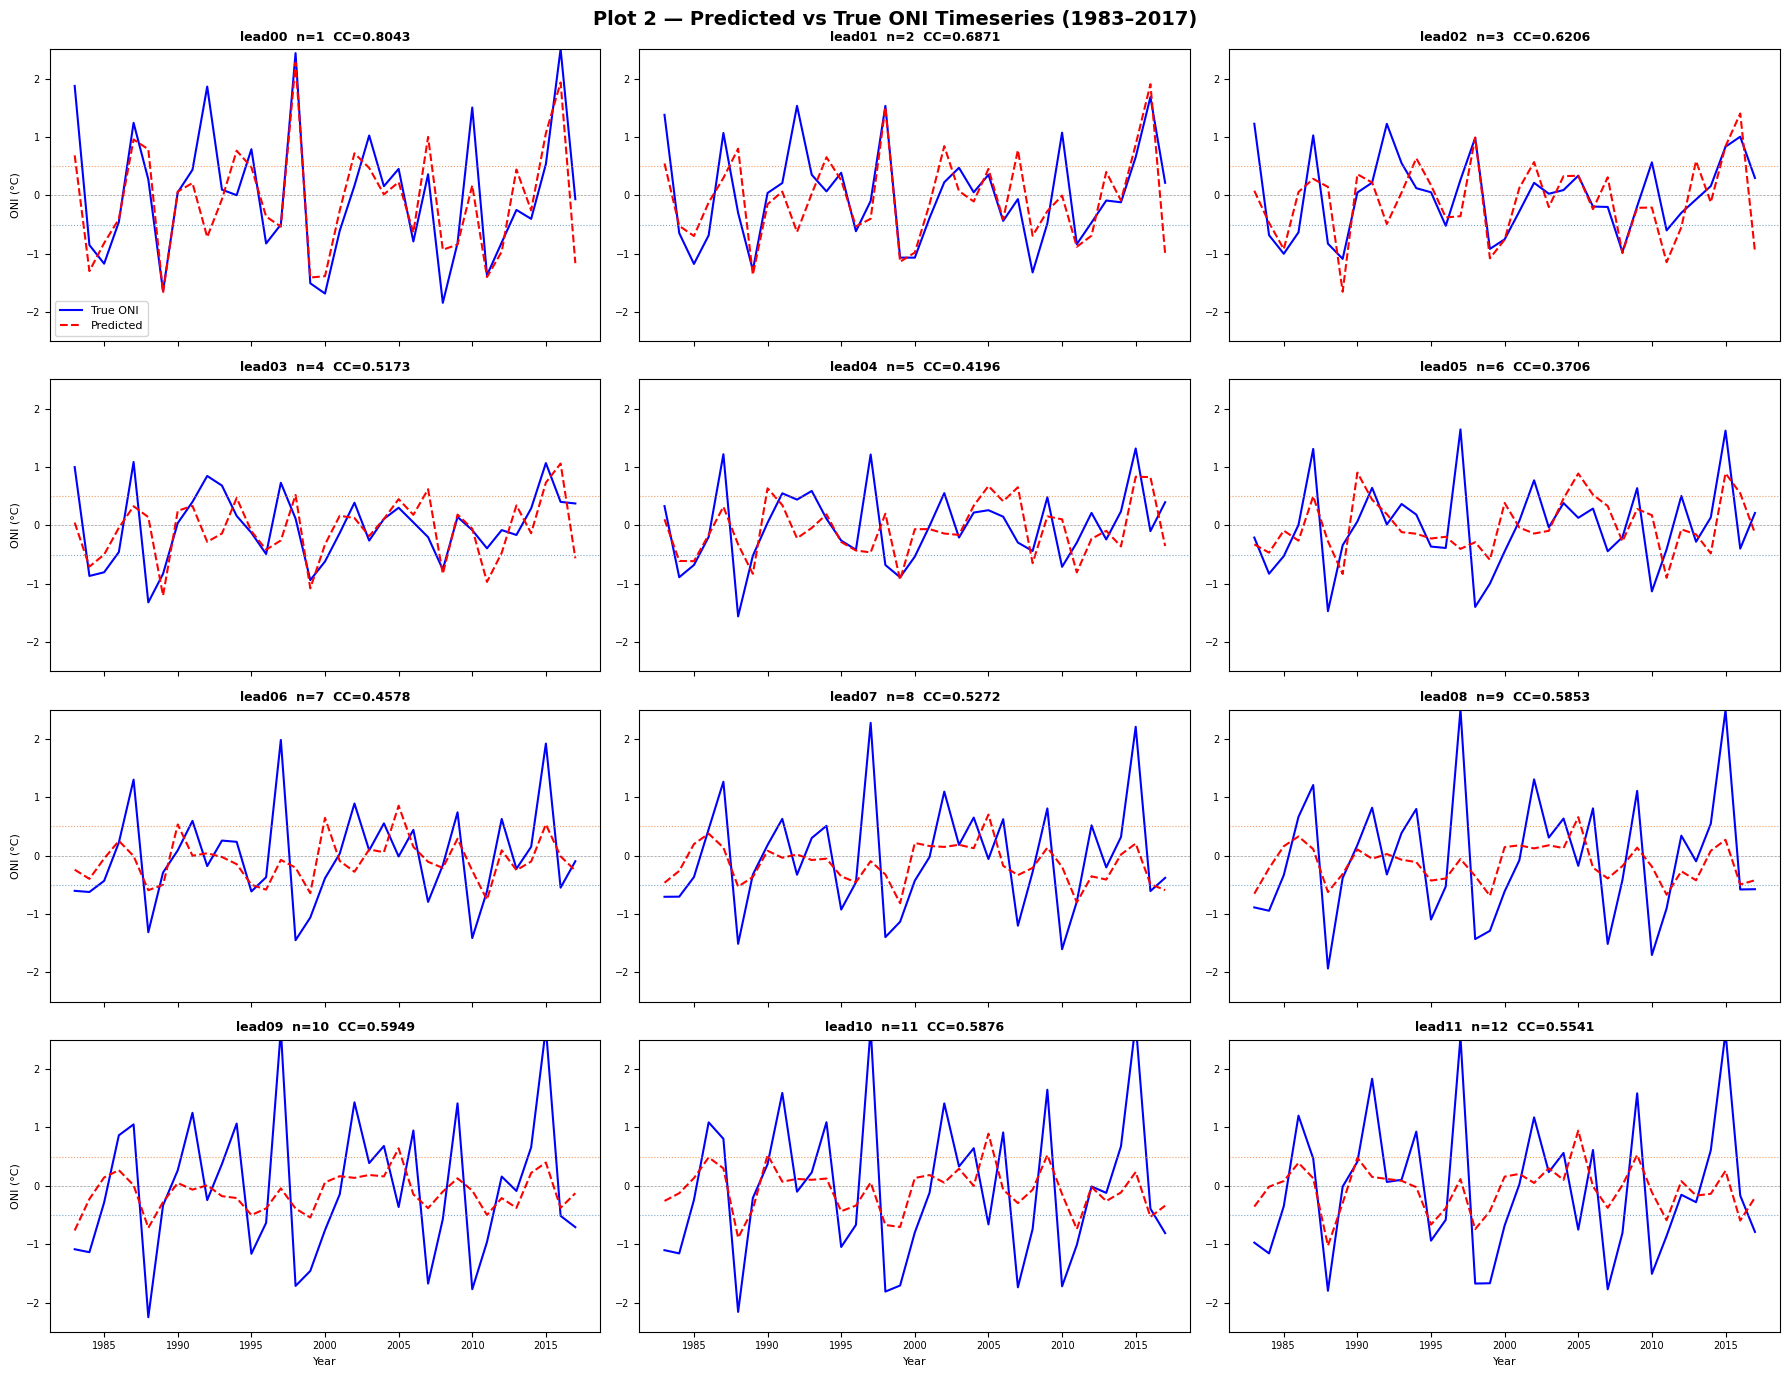

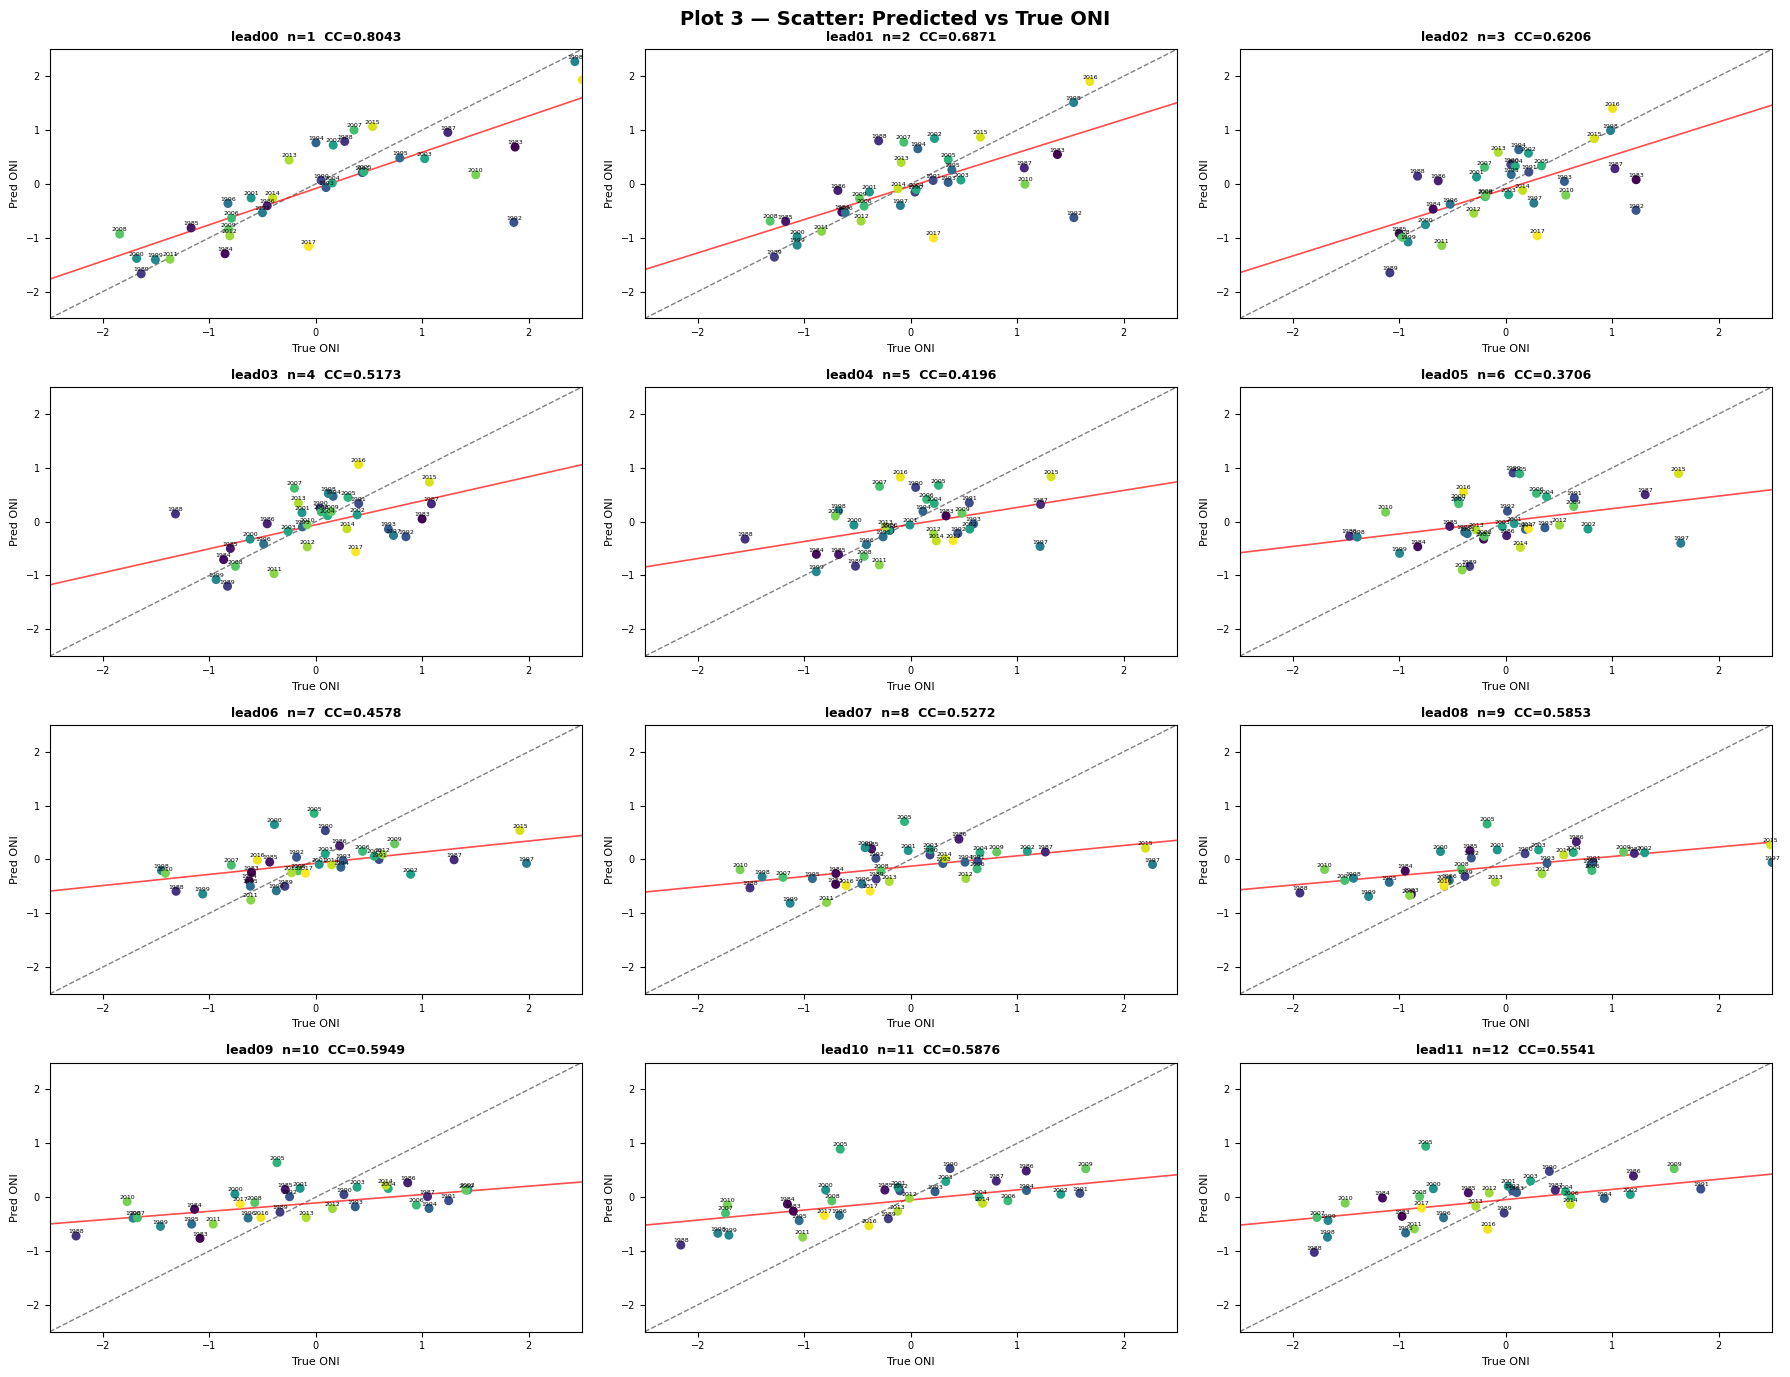

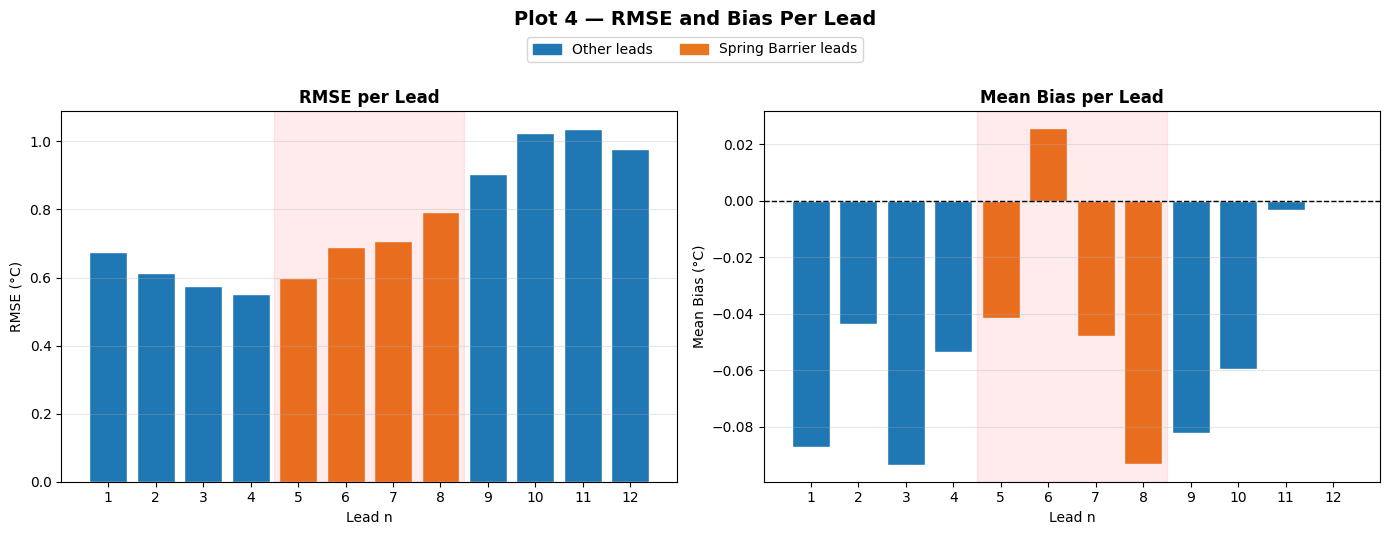

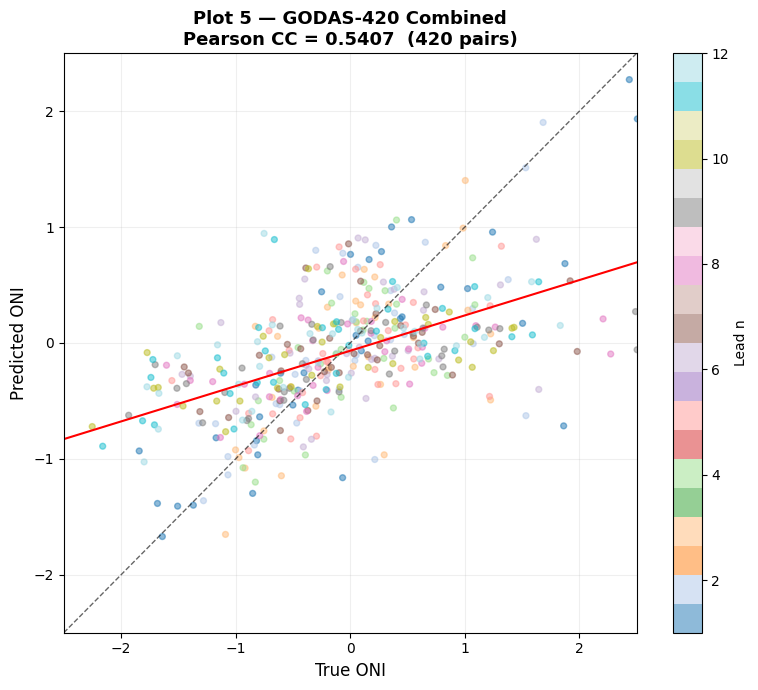

Combined CC = 0.5407


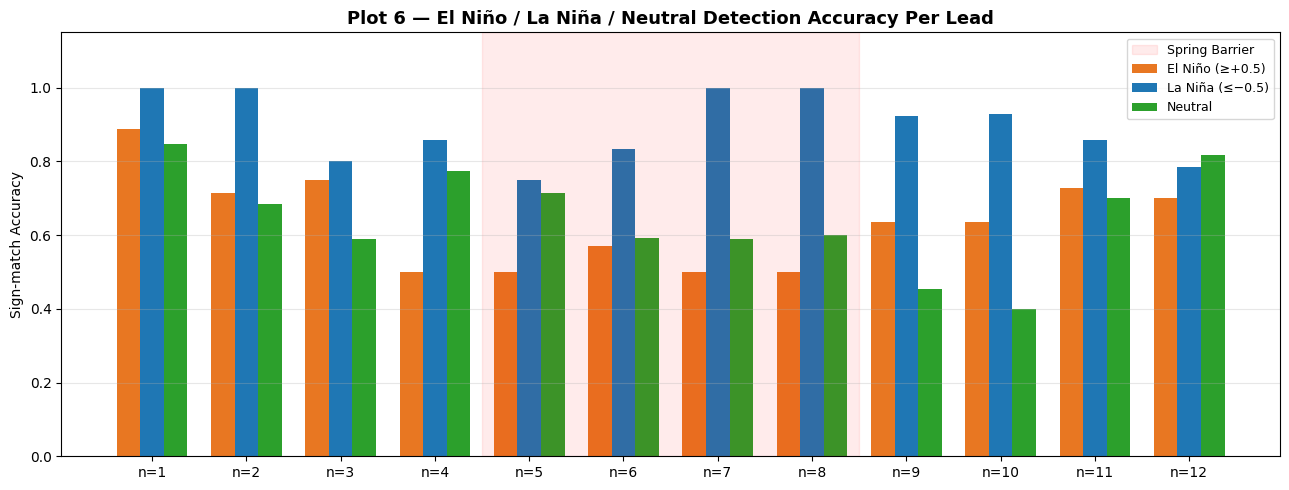

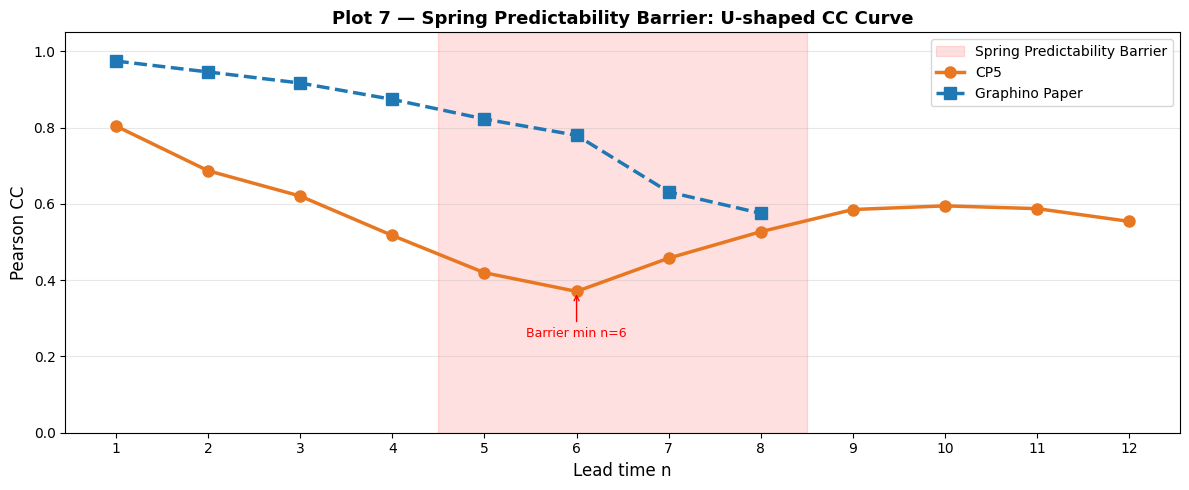

All 7 plots done.


In [ ]:
# ── Plot 2 — Predicted vs True ONI Timeseries (4×3 grid) ──
fig, axes = plt.subplots(4, 3, figsize=(18, 14), sharex=True)
for lead, ax in enumerate(axes.flatten()):
    ax.plot(YEARS, all_labels[lead], 'b-',  lw=1.5, label='True ONI')
    ax.plot(YEARS, all_preds[lead],  'r--', lw=1.5, label='Predicted')
    ax.axhline( 0.5, color='#E87722',   lw=0.8, ls=':', alpha=0.7)
    ax.axhline(-0.5, color='steelblue', lw=0.8, ls=':', alpha=0.7)
    ax.axhline(0,    color='k',         lw=0.5, ls='--', alpha=0.4)
    ax.set_title(f'lead{lead:02d}  n={lead+1}  CC={cp5_cc[lead]:.4f}', fontsize=9, fontweight='bold')
    ax.set_ylim(-2.5, 2.5)
    ax.tick_params(labelsize=7)
    if lead >= 9: ax.set_xlabel('Year', fontsize=8)
    if lead % 3 == 0: ax.set_ylabel('ONI (°C)', fontsize=8)
axes.flatten()[0].legend(fontsize=8)
fig.suptitle('Plot 2 — Predicted vs True ONI Timeseries (1983–2017)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3 — Scatter Plots (4×3 grid) ──
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
for lead, ax in enumerate(axes.flatten()):
    Y, P = all_labels[lead], all_preds[lead]
    lim = (-2.5, 2.5)
    ax.plot(lim, lim, 'k--', lw=1, alpha=0.5)
    slope, intercept, *_ = linregress(Y, P)
    x_line = np.linspace(*lim, 100)
    ax.plot(x_line, slope * x_line + intercept, 'r-', lw=1.2, alpha=0.7)
    ax.scatter(Y, P, c=YEARS, cmap='viridis', s=30, zorder=3)
    for i, yr in enumerate(YEARS):
        ax.annotate(str(yr), (Y[i], P[i]), fontsize=4.5, ha='center',
                    xytext=(0, 2), textcoords='offset points')
    ax.set_xlim(*lim); ax.set_ylim(*lim)
    ax.set_title(f'lead{lead:02d}  n={lead+1}  CC={cp5_cc[lead]:.4f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('True ONI', fontsize=8); ax.set_ylabel('Pred ONI', fontsize=8)
    ax.tick_params(labelsize=7)
fig.suptitle('Plot 3 — Scatter: Predicted vs True ONI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 4 — RMSE and Bias ──
n_vals  = [l + 1 for l in range(12)]
rmse    = [np.sqrt(np.mean((all_preds[l] - all_labels[l])**2)) for l in range(12)]
bias    = [np.mean(all_preds[l] - all_labels[l]) for l in range(12)]
colors  = ['#E87722' if 5 <= n <= 8 else '#1F77B4' for n in n_vals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(n_vals, rmse, color=colors, edgecolor='white')
ax1.axvspan(4.5, 8.5, alpha=0.08, color='red')
ax1.set_xlabel('Lead n'); ax1.set_ylabel('RMSE (°C)')
ax1.set_title('RMSE per Lead', fontweight='bold'); ax1.set_xticks(n_vals); ax1.grid(axis='y', alpha=0.3)
ax2.bar(n_vals, bias, color=colors, edgecolor='white')
ax2.axvspan(4.5, 8.5, alpha=0.08, color='red')
ax2.axhline(0, color='k', lw=1, ls='--')
ax2.set_xlabel('Lead n'); ax2.set_ylabel('Mean Bias (°C)')
ax2.set_title('Mean Bias per Lead', fontweight='bold'); ax2.set_xticks(n_vals); ax2.grid(axis='y', alpha=0.3)
fig.legend(handles=[mpatches.Patch(color='#1F77B4', label='Other leads'),
                    mpatches.Patch(color='#E87722', label='Spring Barrier leads')],
           loc='upper center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Plot 4 — RMSE and Bias Per Lead', fontsize=14, fontweight='bold', y=1.06)
plt.tight_layout()
plt.savefig('plot4_rmse_bias.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 5 — GODAS-420 Combined ──
all_p = np.concatenate(all_preds)
all_y = np.concatenate(all_labels)
all_l = np.concatenate([[l+1]*35 for l in range(12)])
combined_cc = pearsonr(all_p, all_y)[0]

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(all_y, all_p, c=all_l, cmap='tab20', alpha=0.5, s=18)
lim = (-2.5, 2.5)
ax.plot(lim, lim, 'k--', lw=1, alpha=0.6)
slope, intercept, *_ = linregress(all_y, all_p)
x_line = np.linspace(*lim, 100)
ax.plot(x_line, slope * x_line + intercept, 'r-', lw=1.5)
plt.colorbar(sc, ax=ax, label='Lead n')
ax.set_xlim(*lim); ax.set_ylim(*lim)
ax.set_xlabel('True ONI', fontsize=12); ax.set_ylabel('Predicted ONI', fontsize=12)
ax.set_title(f'Plot 5 — GODAS-420 Combined\nPearson CC = {combined_cc:.4f}  (420 pairs)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('plot5_combined.png', dpi=150)
plt.show()
print(f'Combined CC = {combined_cc:.4f}')

# ── Plot 6 — Detection Accuracy ──
def det_acc(P, Y, thr=0.5):
    results = []
    for mask in [Y >= thr, Y <= -thr, (Y > -thr) & (Y < thr)]:
        results.append(np.mean(np.sign(P[mask]) == np.sign(Y[mask])) if mask.sum() > 0 else np.nan)
    return results

en_acc, ln_acc, neu_acc = zip(*[det_acc(all_preds[l], all_labels[l]) for l in range(12)])
x = np.arange(12); w = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w, en_acc,  w, label='El Niño (≥+0.5)',  color='#E87722')
ax.bar(x,     ln_acc,  w, label='La Niña (≤−0.5)',  color='#1F77B4')
ax.bar(x + w, neu_acc, w, label='Neutral',           color='#2CA02C')
ax.axvspan(3.5, 7.5, alpha=0.08, color='red', label='Spring Barrier')
ax.set_xticks(x); ax.set_xticklabels([f'n={l+1}' for l in range(12)])
ax.set_ylim(0, 1.15); ax.set_ylabel('Sign-match Accuracy')
ax.set_title('Plot 6 — El Niño / La Niña / Neutral Detection Accuracy Per Lead',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot6_detection.png', dpi=150)
plt.show()

# ── Plot 7 — Spring Predictability Barrier ──
fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(4.5, 8.5, alpha=0.12, color='red', label='Spring Predictability Barrier')
ax.plot(n_vals, [cp5_cc[l] for l in range(12)], 'o-', color='#E87722', lw=2.5, ms=8, label='CP5')
ax.plot(sorted(PAPER_CC), [PAPER_CC[n] for n in sorted(PAPER_CC)],
        's--', color='#1F77B4', lw=2.5, ms=8, label='Graphino Paper')
min_lead = min(cp5_cc, key=cp5_cc.get)
ax.annotate(f'Barrier min n={min_lead+1}', xy=(min_lead+1, cp5_cc[min_lead]),
            xytext=(min_lead+1, cp5_cc[min_lead] - 0.12),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red', ha='center')
ax.set_xlabel('Lead time n', fontsize=12); ax.set_ylabel('Pearson CC', fontsize=12)
ax.set_title('Plot 7 — Spring Predictability Barrier: U-shaped CC Curve', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 13)); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot7_spring_barrier.png', dpi=150)
plt.show()

print('All 7 plots done.')